# IMDb Sentiment Classifier

## Objective
Classify movie reviews as positive or negative using classical Natural Language Processing.

## Models compared
- Dummy baseline
- Multinomial Naive Bayes
- Logistic Regression

## Important limitation
The model predicts sentiment from text. It does not understand films like a person and can misinterpret sarcasm, irony, or mixed reviews.

In [31]:
!pip install -q tensorflow scikit-learn pandas matplotlib seaborn

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import imdb

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
VOCAB_SIZE = 10_000

In [33]:
(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

word_index = imdb.get_word_index()

reverse_word_index = {
    index + 3: word
    for word, index in word_index.items()
}

reverse_word_index[0] = "[PAD]"
reverse_word_index[1] = "[START]"
reverse_word_index[2] = "[OOV]"
reverse_word_index[3] = "[UNUSED]"

def decode_review(encoded_review):
    return " ".join(
        reverse_word_index.get(index, "[UNKNOWN]")
        for index in encoded_review
    )

X_train_text = [decode_review(review) for review in X_train_raw]
X_test_text = [decode_review(review) for review in X_test_raw]

print("Training reviews:", len(X_train_text))
print("Test reviews:", len(X_test_text))
print("\nExample review:\n")
print(X_train_text[0][:1000])
print("\nLabel:", "Positive" if y_train[0] == 1 else "Negative")

Training reviews: 25000
Test reviews: 25000

Example review:

[START] this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert [OOV] is an amazing actor and now the same being director [OOV] father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for [OOV] and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also [OOV] to the two little boy's that played the [OOV] of norman and paul they were just brilliant children are often left out of the [OOV] list i think because the stars that play them all grown up are such a big profile for the whole fil

## Exploratory Data Analysis

I check class balance and review length before training the models.

sentiment_name
Positive    12500
Negative    12500
Name: count, dtype: int64


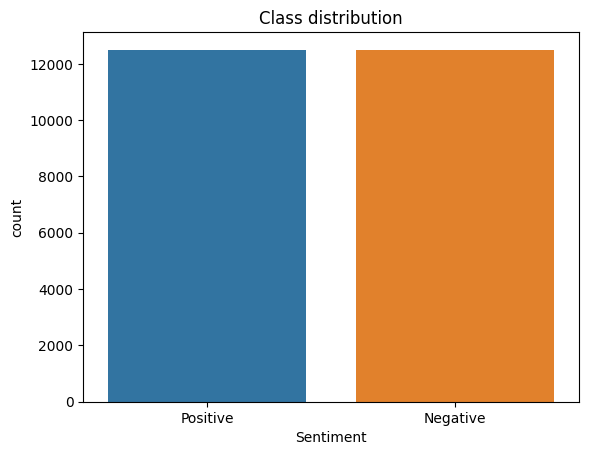

In [34]:
train_df = pd.DataFrame({
    "review": X_train_text,
    "sentiment": y_train
})

train_df["sentiment_name"] = train_df["sentiment"].map({
    0: "Negative",
    1: "Positive"
})

train_df["word_count"] = train_df["review"].str.split().str.len()

print(train_df["sentiment_name"].value_counts())

sns.countplot(
    data=train_df,
    x="sentiment_name",
    hue="sentiment_name",
    legend=False
)
plt.title("Class distribution")
plt.xlabel("Sentiment")
plt.show()

count    25000.000000
mean       238.710480
std        176.492037
min         11.000000
25%        130.000000
50%        178.000000
75%        291.000000
max       2494.000000
Name: word_count, dtype: float64


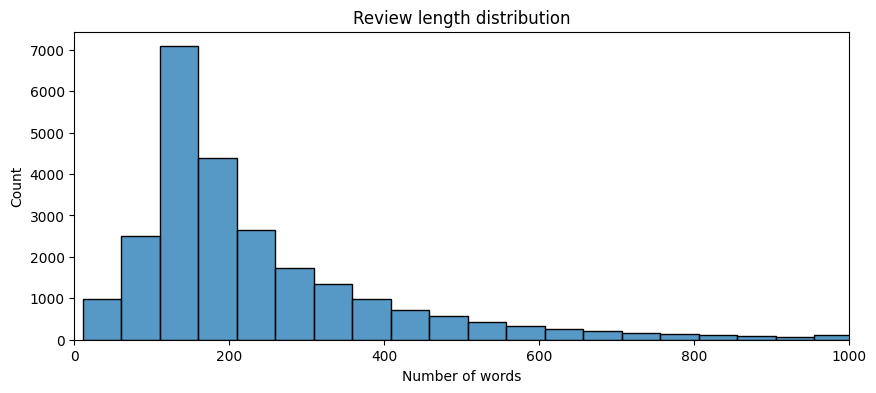

In [35]:
print(train_df["word_count"].describe())

plt.figure(figsize=(10, 4))
sns.histplot(train_df["word_count"], bins=50)
plt.xlim(0, 1000)
plt.title("Review length distribution")
plt.xlabel("Number of words")
plt.show()

In [36]:
X_train, X_val, y_train_split, y_val = train_test_split(
    X_train_text,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 20000
Validation samples: 5000


In [37]:
baseline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline.fit(X_train, y_train_split)
baseline_pred = baseline.predict(X_val)

print("Baseline accuracy:", round(accuracy_score(y_val, baseline_pred), 4))
print("Baseline F1:", round(f1_score(y_val, baseline_pred), 4))

Baseline accuracy: 0.5
Baseline F1: 0.0


In [38]:
naive_bayes_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.90,
        sublinear_tf=True
    )),
    ("model", MultinomialNB(alpha=0.3))
])

naive_bayes_model.fit(X_train, y_train_split)
nb_pred = naive_bayes_model.predict(X_val)

print("Naive Bayes accuracy:", round(accuracy_score(y_val, nb_pred), 4))
print("Naive Bayes F1:", round(f1_score(y_val, nb_pred), 4))

Naive Bayes accuracy: 0.8794
Naive Bayes F1: 0.8789


In [39]:
logistic_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.90,
        sublinear_tf=True
    )),
    ("model", LogisticRegression(
        max_iter=2000,
        C=1.0,
        random_state=RANDOM_STATE
    ))
])

logistic_model.fit(X_train, y_train_split)
logistic_pred = logistic_model.predict(X_val)

print("Logistic Regression accuracy:", round(accuracy_score(y_val, logistic_pred), 4))
print("Logistic Regression F1:", round(f1_score(y_val, logistic_pred), 4))

Logistic Regression accuracy: 0.8876
Logistic Regression F1: 0.8897


In [40]:
results = pd.DataFrame({
    "Model": ["Dummy baseline", "Naive Bayes", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_val, baseline_pred),
        accuracy_score(y_val, nb_pred),
        accuracy_score(y_val, logistic_pred)
    ],
    "Precision": [
        precision_score(y_val, baseline_pred, zero_division=0),
        precision_score(y_val, nb_pred),
        precision_score(y_val, logistic_pred)
    ],
    "Recall": [
        recall_score(y_val, baseline_pred, zero_division=0),
        recall_score(y_val, nb_pred),
        recall_score(y_val, logistic_pred)
    ],
    "F1": [
        f1_score(y_val, baseline_pred, zero_division=0),
        f1_score(y_val, nb_pred),
        f1_score(y_val, logistic_pred)
    ]
})

results.sort_values("F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1
2,Logistic Regression,0.8876,0.873554,0.9064,0.889674
1,Naive Bayes,0.8794,0.882614,0.8752,0.878891
0,Dummy baseline,0.5000,0.000000,0.0000,0.000000


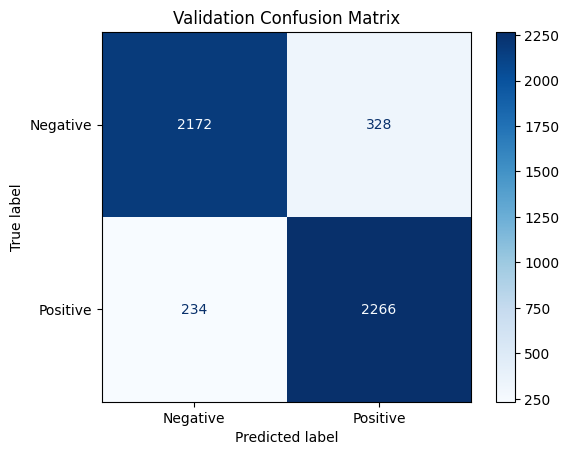

In [41]:
best_pred = logistic_pred

cm = confusion_matrix(y_val, best_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

display.plot(cmap="Blues")
plt.title("Validation Confusion Matrix")
plt.show()

In [42]:
errors = pd.DataFrame({
    "review": X_val,
    "true_sentiment": y_val,
    "predicted_sentiment": best_pred
})

errors["true_label"] = errors["true_sentiment"].map({
    0: "Negative",
    1: "Positive"
})

errors["predicted_label"] = errors["predicted_sentiment"].map({
    0: "Negative",
    1: "Positive"
})

mistakes = errors[
    errors["true_sentiment"] != errors["predicted_sentiment"]
]

print("Number of mistakes:", len(mistakes))

mistakes[
    ["review", "true_label", "predicted_label"]
].head(10)

Number of mistakes: 562


,review,true_label,predicted_label
7,[START] chris rock apparently desperate for a ...,Negative,Positive
8,[START] cradle of fear br br this isn't a movi...,Negative,Positive
31,[START] well the movie isn't exactly funny br ...,Positive,Negative
33,[START] this was a strong [OOV] [OOV] televisi...,Positive,Negative
34,[START] all [OOV] go to heaven is an animated ...,Positive,Negative
37,[START] ok this one's a [OOV] honestly i can't...,Positive,Negative
57,[START] unless i'm sadly mistaken i rented a n...,Negative,Positive
93,[START] even though an animated film it really...,Negative,Positive
109,[START] this movie has a very broadway feel th...,Negative,Positive
117,[START] everyone knows about this [OOV] [OOV] ...,Positive,Negative


In [43]:
vectorizer = logistic_model.named_steps["tfidf"]
classifier = logistic_model.named_steps["model"]

feature_names = vectorizer.get_feature_names_out()
coefficients = classifier.coef_[0]

top_positive = np.argsort(coefficients)[-15:][::-1]
top_negative = np.argsort(coefficients)[:15]

print("Words most associated with POSITIVE sentiment:")
print(feature_names[top_positive])

print("\nWords most associated with NEGATIVE sentiment:")
print(feature_names[top_negative])

Words most associated with POSITIVE sentiment:
['great' 'excellent' 'wonderful' 'best' 'the best' 'perfect' 'love'
 'amazing' 'well' 'fun' 'loved' 'beautiful' 'also' 'both' 'is great']

Words most associated with NEGATIVE sentiment:
['bad' 'worst' 'the worst' 'awful' 'boring' 'waste' 'poor' 'no' 'nothing'
 'terrible' 'worse' 'stupid' 'dull' 'even' 'horrible']


In [44]:
final_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.90,
        sublinear_tf=True
    )),
    ("model", LogisticRegression(
        max_iter=2000,
        C=1.0,
        random_state=RANDOM_STATE
    ))
])

final_model.fit(X_train_text, y_train)
test_pred = final_model.predict(X_test_text)

print("Test accuracy:", round(accuracy_score(y_test, test_pred), 4))
print("Test precision:", round(precision_score(y_test, test_pred), 4))
print("Test recall:", round(recall_score(y_test, test_pred), 4))
print("Test F1:", round(f1_score(y_test, test_pred), 4))

print("\nClassification report:\n")
print(classification_report(
    y_test,
    test_pred,
    target_names=["Negative", "Positive"]
))

Test accuracy: 0.8949
Test precision: 0.8889
Test recall: 0.9026
Test F1: 0.8957

Classification report:

              precision    recall  f1-score   support

    Negative       0.90      0.89      0.89     12500
    Positive       0.89      0.90      0.90     12500

    accuracy                           0.89     25000
   macro avg       0.90      0.89      0.89     25000
weighted avg       0.90      0.89      0.89     25000



In [45]:
reviews = [
    "A beautiful film with excellent acting and an emotional ending.",
    "The story was boring, slow and completely predictable.",
    "The visuals were good, but the plot was confusing and the ending was disappointing."
]

predictions = final_model.predict(reviews)
probabilities = final_model.predict_proba(reviews)

for review, prediction, probability in zip(reviews, predictions, probabilities):
    label = "Positive" if prediction == 1 else "Negative"
    confidence = probability[prediction]

    print(f"Review: {review}")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.1%}\n")

Review: A beautiful film with excellent acting and an emotional ending.
Prediction: Positive
Confidence: 89.8%

Review: The story was boring, slow and completely predictable.
Prediction: Negative
Confidence: 91.1%

Review: The visuals were good, but the plot was confusing and the ending was disappointing.
Prediction: Negative
Confidence: 82.3%

